# FinAuditAI — 3주차 데이터 전처리 및 XGBoost 고도화 비교

이 노트북은 기존 **`FinAuditAI_3주차_데이터전처리`**의 전처리 틀을 유지하면서,
기존 XGBoost Baseline과 고도화 XGBoost 후보를 동일 조건에서 비교하도록 확장한 통합본이다.

**핵심 설계**

- Train / Validation / Audit을 60% / 20% / 20%로 분리한다.
- Validation은 Early Stopping과 모델 후보 선정에 사용한다.
- Audit은 모델 선정 후 일반화 성능을 최종 검증하는 데 사용한다.
- 민감변수는 모델 학습에서 제외하고 Fairlearn 감사 데이터에만 보관한다.
- 범주형 변수는 `category` dtype으로 유지하여 SHAP 결과를 원래 변수 단위로 보존한다.
- 개선 후보가 Audit에서 개선 효과를 재현하지 못하면 고도화 성공으로 확정하지 않고 재실험 대상으로 기록한다.

- 데이터: Home Credit Default Risk (`application_train.csv`)
- 모델: XGBoost
- 고정 시드: `random_state=42`


In [5]:
from google.colab import drive
drive.mount('/content/drive')

!pip install -q xgboost
!apt-get -qq install -y fonts-nanum > /dev/null

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
import os
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb

from pandas.api.types import is_numeric_dtype
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
    log_loss,
    accuracy_score,
    roc_curve,
)

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
TARGET_COL = "TARGET" # 정답 컬럼
ID_COL = "SK_ID_CURR" # 식별자 컬럼
OUTPUT_DIR = "/content/drive/MyDrive/data/outputs_total"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("pandas:", pd.__version__)
print("xgboost:", xgb.__version__)
print("출력 폴더:", OUTPUT_DIR)

pandas: 2.2.2
xgboost: 3.3.0
출력 폴더: /content/drive/MyDrive/data/outputs_total


In [7]:
import matplotlib.font_manager as fm

# NanumGothic 폰트 경로 등록 (Cell 1에서 apt-get으로 설치한 폰트)
for font_path in fm.findSystemFonts(fontpaths=["/usr/share/fonts/truetype/nanum"]):
    fm.fontManager.addfont(font_path)

plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False  # 마이너스 기호 깨짐 방지

## 1. 데이터 불러오기 — 핵심설계: 원본 무결성 확인

`application_train.csv`를 로드하고 다음 내용을 먼저 확인한다.

- 전체 행·열 크기
- 중복 행
- 식별자 중복
- TARGET 클래스 분포와 연체 비율
- 원본 주요 컬럼의 데이터 타입

원본 상태를 먼저 기록해야 이후 전처리 과정에서 몇 건이 제거되거나 변환되었는지 추적할 수 있다.


In [8]:
DATA_PATH = "/content/drive/MyDrive/data/application_train.csv"

df = pd.read_csv(DATA_PATH)

required_cols = {
    "SK_ID_CURR", "TARGET", "CODE_GENDER",
    "DAYS_BIRTH", "DAYS_EMPLOYED"
}

# 필수 컬럼 5개가 실제 데이터에 있는지 집합 연산으로 확인
missing_required = required_cols - set(df.columns)
if missing_required:
    raise ValueError(f"필수 컬럼 누락: {sorted(missing_required)}")

print("원본 shape:", df.shape)
print("전체 중복 행:", int(df.duplicated().sum()))
print("SK_ID_CURR 중복:", int(df["SK_ID_CURR"].duplicated().sum()))
print("\nTARGET 건수:")
print(df[TARGET_COL].value_counts().sort_index())
print("\nTARGET 비율:")
print(df[TARGET_COL].value_counts(normalize=True).sort_index())
print("\n주요 컬럼 dtype:")
print(df[["SK_ID_CURR", "TARGET", "CODE_GENDER", "DAYS_BIRTH", "DAYS_EMPLOYED"]].dtypes)

원본 shape: (307511, 122)
전체 중복 행: 0
SK_ID_CURR 중복: 0

TARGET 건수:
TARGET
0    282686
1     24825
Name: count, dtype: int64

TARGET 비율:
TARGET
0    0.919271
1    0.080729
Name: proportion, dtype: float64

주요 컬럼 dtype:
SK_ID_CURR        int64
TARGET            int64
CODE_GENDER      object
DAYS_BIRTH        int64
DAYS_EMPLOYED     int64
dtype: object


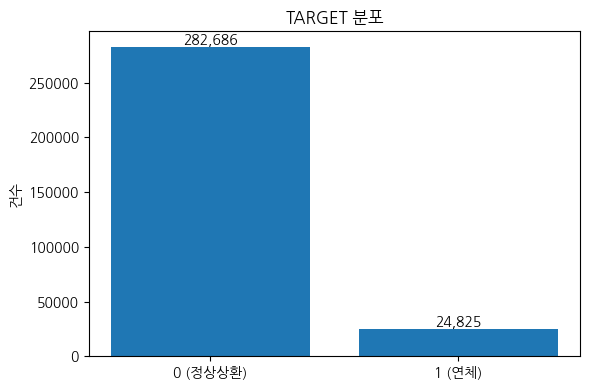

In [9]:
target_counts = df[TARGET_COL].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(["0 (정상상환)", "1 (연체)"], target_counts.values)
for i, value in enumerate(target_counts.values):
    ax.text(i, value, f"{value:,}", ha="center", va="bottom")
ax.set_title("TARGET 분포")
ax.set_ylabel("건수")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/target_distribution.png", dpi=150)
plt.show()

## 2. 데이터 클렌징 — 핵심설계: 이상치·센티널 값 제거

- `CODE_GENDER == 'XNA'`: 성별 미상 이상치이므로 제거한다.
- `DAYS_EMPLOYED == 365243`: 약 1,000년 근무로 기록된 센티널 값이다.
- 센티널 여부는 `IS_RETIRED` 플래그로 먼저 보존한 뒤 `DAYS_EMPLOYED`를 `NaN`으로 치환한다.
- 나머지 결측치는 별도로 대치하지 않고 XGBoost의 네이티브 결측 분기 처리를 사용한다.

`IS_RETIRED`를 먼저 생성하는 이유는 센티널 값이 단순 오류가 아니라 무직·연금수급 상태에 관한 정보를 포함할 수 있기 때문이다.


In [10]:
before_rows = len(df)
xna_count = int((df["CODE_GENDER"] == "XNA").sum())

df = df[df["CODE_GENDER"] != "XNA"].copy()

sentinel_count = int((df["DAYS_EMPLOYED"] == 365243).sum())
df["IS_RETIRED"] = (df["DAYS_EMPLOYED"] == 365243).astype("int8")
df["DAYS_EMPLOYED"] = df["DAYS_EMPLOYED"].replace(365243, np.nan)

print(f"CODE_GENDER=XNA 제거: {xna_count}건")
print("XNA 제거 후 shape:", df.shape)
print(f"DAYS_EMPLOYED 센티널값 → NaN: {sentinel_count}건")
print("IS_RETIRED=1:", int(df["IS_RETIRED"].sum()), "건")
print("제거된 전체 행:", before_rows - len(df))

CODE_GENDER=XNA 제거: 4건
XNA 제거 후 shape: (307507, 123)
DAYS_EMPLOYED 센티널값 → NaN: 55374건
IS_RETIRED=1: 55374 건
제거된 전체 행: 4


결측치가 존재하는 컬럼 수: 68 / 123


,missing_percent
COMMONAREA_AVG,69.87
COMMONAREA_MEDI,69.87
COMMONAREA_MODE,69.87
NONLIVINGAPARTMENTS_MODE,69.43
NONLIVINGAPARTMENTS_MEDI,69.43
NONLIVINGAPARTMENTS_AVG,69.43
FONDKAPREMONT_MODE,68.39
LIVINGAPARTMENTS_MEDI,68.36
LIVINGAPARTMENTS_MODE,68.36
LIVINGAPARTMENTS_AVG,68.36


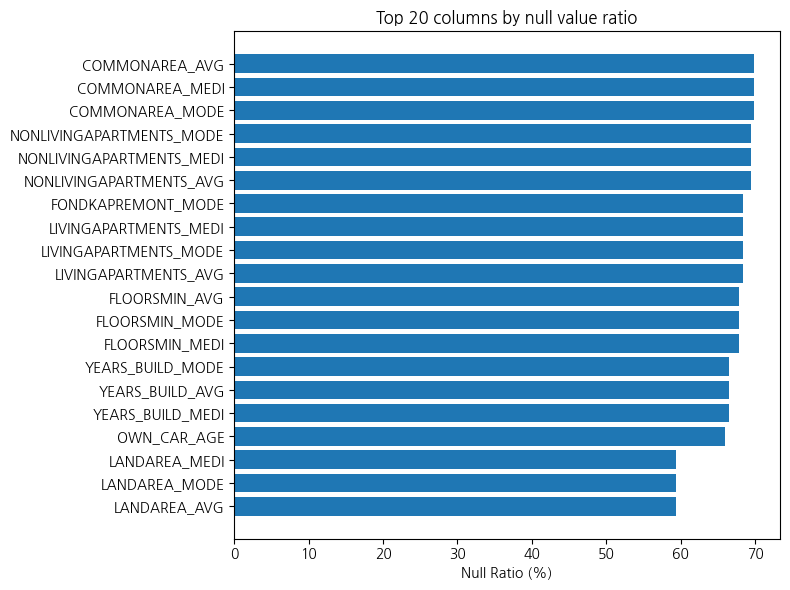

In [11]:
missing_ratio = df.isna().mean().sort_values(ascending=False)
top_missing = missing_ratio[missing_ratio > 0].head(20)

print(f"결측치가 존재하는 컬럼 수: {(missing_ratio > 0).sum()} / {df.shape[1]}")
display((top_missing * 100).round(2).to_frame("missing_percent"))

fig, ax = plt.subplots(figsize=(8, 6))
plot_missing = top_missing.iloc[::-1] * 100
ax.barh(plot_missing.index, plot_missing.values)
ax.set_title("Top 20 columns by null value ratio")
ax.set_xlabel("Null Ratio (%)")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/missing_ratio_top20.png", dpi=150)
plt.show()

## 3. 파생 변수 생성 — 핵심설계: 공정성 분석용 연령 구간화

`DAYS_BIRTH`는 신청일을 기준으로 출생일까지의 일수를 음수로 기록한 정수형 변수다.

- `AGE`: `-DAYS_BIRTH / 365`를 정수 나이로 변환
- `AGE_GROUP`: Fairlearn 공정성 분석용 연령 구간
- `AGE`와 `AGE_GROUP`은 모델 학습 피처가 아니라 감사용 민감정보로만 사용

연령 구간은 기존 발표자료와 `audit_evidence.json`의 기준에 맞춰 다음 5개 그룹으로 고정한다.

`20대이하 / 30대 / 40대 / 50대 / 60대이상`


In [12]:
# DAYS_BIRTH는 원본에서도 정수형이지만 타입을 명시적으로 확인한다.
if not is_numeric_dtype(df["DAYS_BIRTH"]):
    raise TypeError("DAYS_BIRTH는 숫자형이어야 합니다.")

df["DAYS_BIRTH"] = df["DAYS_BIRTH"].astype("int64")
df["AGE"] = (-df["DAYS_BIRTH"] / 365).astype("int64")

df["AGE_GROUP"] = pd.cut(
    df["AGE"],
    bins=[0, 30, 40, 50, 60, 200],
    labels=["20대이하", "30대", "40대", "50대", "60대이상"],
    include_lowest=True,
)

print(df[["DAYS_BIRTH", "AGE", "AGE_GROUP"]].head())
print("\nAGE_GROUP 분포:")
print(df["AGE_GROUP"].value_counts().sort_index())
print("\ndtype 확인:")
print(df[["DAYS_BIRTH", "AGE", "AGE_GROUP"]].dtypes)

   DAYS_BIRTH  AGE AGE_GROUP
0       -9461   25     20대이하
1      -16765   45       40대
2      -19046   52       50대
3      -19005   52       50대
4      -19932   54       50대

AGE_GROUP 분포:
AGE_GROUP
20대이하    52804
30대      83116
40대      74401
50대      67818
60대이상    29368
Name: count, dtype: int64

dtype 확인:
DAYS_BIRTH       int64
AGE              int64
AGE_GROUP     category
dtype: object


## 4. 컬럼 정리 — 핵심설계: 정보량이 없거나 합의상 제외한 변수 제거

기존 전처리 노트북의 틀을 유지하면서 프로젝트 팀이 합의한 제외 기준을 함께 반영한다.

- `EXT_SOURCE_1/2/3`: 원본 컬럼명 유지
- `FLAG_MOBIL`: 거의 모든 행이 동일한 값이므로 제외
- 서류 제출 여부 컬럼: 모델 학습에서 제외
- 신청 요일·시간 컬럼: 모델 학습에서 제외
- 주거 건물 상세 컬럼: 모델 학습에서 제외
- 성별·나이 관련 컬럼: 모델 학습에서는 제외하지만 감사용으로 별도 보관

제외 목록은 결과 파일로 저장하여 모델 정의서와 데이터 정의서에서 추적할 수 있게 한다.


In [13]:
print("EXT_SOURCE 컬럼명 유지:", [c for c in df.columns if c.startswith("EXT_SOURCE")])

DOCUMENT_COLS = [
    f"FLAG_DOCUMENT_{i}"
    for i in range(2, 22)
    if f"FLAG_DOCUMENT_{i}" in df.columns
]
TIME_COLS = [
    c for c in ["WEEKDAY_APPR_PROCESS_START", "HOUR_APPR_PROCESS_START"]
    if c in df.columns
]
ZERO_INFO_COLS = [
    c for c in ["FLAG_MOBIL"]
    if c in df.columns and df[c].nunique(dropna=False) <= 2
]
HOUSING_KEYWORDS = [
    "APARTMENT", "BASEMENTAREA", "YEARS_BEGINEXPLUATATION", "YEARS_BUILD",
    "COMMONAREA", "ELEVATORS", "ENTRANCES", "FLOORSMAX", "FLOORSMIN",
    "LANDAREA", "LIVINGAPARTMENTS", "LIVINGAREA", "NONLIVINGAPARTMENTS",
    "NONLIVINGAREA", "FONDKAPREMONT", "HOUSETYPE", "TOTALAREA",
    "WALLSMATERIAL", "EMERGENCYSTATE",
]
HOUSING_COLS = [
    c for c in df.columns
    if any(keyword in c for keyword in HOUSING_KEYWORDS)
]

SENSITIVE_COLS = ["CODE_GENDER", "DAYS_BIRTH", "AGE", "AGE_GROUP"]

EXCLUDE_REASON_MAP = {}
for col in DOCUMENT_COLS:
    EXCLUDE_REASON_MAP[col] = "서류 제출 여부"
for col in TIME_COLS:
    EXCLUDE_REASON_MAP[col] = "신청 요일·시간"
for col in ZERO_INFO_COLS:
    EXCLUDE_REASON_MAP[col] = "정보량 부족"
for col in HOUSING_COLS:
    EXCLUDE_REASON_MAP[col] = "주거 건물 상세"
for col in SENSITIVE_COLS:
    EXCLUDE_REASON_MAP[col] = "민감정보·감사용"

exclude_definition = pd.DataFrame(
    [{"column": col, "reason": reason} for col, reason in EXCLUDE_REASON_MAP.items()]
).sort_values(["reason", "column"])

exclude_definition.to_csv(
    f"{OUTPUT_DIR}/excluded_feature_definition.csv",
    index=False,
    encoding="utf-8-sig",
)

print("서류 컬럼:", len(DOCUMENT_COLS))
print("시간 컬럼:", len(TIME_COLS))
print("주거 컬럼:", len(HOUSING_COLS))
print("정보량 부족 컬럼:", ZERO_INFO_COLS)
print("전체 학습 제외 컬럼:", len(EXCLUDE_REASON_MAP))
display(exclude_definition.head(20))

EXT_SOURCE 컬럼명 유지: ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']
서류 컬럼: 20
시간 컬럼: 2
주거 컬럼: 47
정보량 부족 컬럼: ['FLAG_MOBIL']
전체 학습 제외 컬럼: 74


,column,reason
72,AGE,민감정보·감사용
73,AGE_GROUP,민감정보·감사용
70,CODE_GENDER,민감정보·감사용
71,DAYS_BIRTH,민감정보·감사용
8,FLAG_DOCUMENT_10,서류 제출 여부
9,FLAG_DOCUMENT_11,서류 제출 여부
10,FLAG_DOCUMENT_12,서류 제출 여부
11,FLAG_DOCUMENT_13,서류 제출 여부
12,FLAG_DOCUMENT_14,서류 제출 여부
13,FLAG_DOCUMENT_15,서류 제출 여부


## 5. 민감변수 정의 — 핵심설계: 학습 제외, 감사에는 포함

민감변수를 모델이 직접 학습하면 직접 차별 가능성이 생길 수 있다. 따라서 다음 컬럼은 학습 피처에서 제외한다.

- `CODE_GENDER`
- `DAYS_BIRTH`
- `AGE`
- `AGE_GROUP`

그러나 Fairlearn으로 집단별 승인률과 오류율을 계산하려면 반드시 필요하므로,
식별자와 TARGET을 포함한 `df_sensitive`에 별도로 보관한다.


In [14]:
AUDIT_KEEP_COLS = [ID_COL] + SENSITIVE_COLS + [TARGET_COL]
df_sensitive = df[AUDIT_KEEP_COLS].copy()

MODEL_EXCLUDE_COLS = (
    [ID_COL, TARGET_COL]
    + SENSITIVE_COLS
    + DOCUMENT_COLS
    + TIME_COLS
    + ZERO_INFO_COLS
    + HOUSING_COLS
)
MODEL_EXCLUDE_COLS = list(dict.fromkeys(
    [c for c in MODEL_EXCLUDE_COLS if c in df.columns]
))

feature_cols = [c for c in df.columns if c not in MODEL_EXCLUDE_COLS]

print("감사용 보관 컬럼:", AUDIT_KEEP_COLS)
print("학습 제외 컬럼 수:", len(MODEL_EXCLUDE_COLS))
print("최종 학습 피처 수:", len(feature_cols))
print("민감변수의 학습 피처 포함 여부:", set(SENSITIVE_COLS).intersection(feature_cols))

감사용 보관 컬럼: ['SK_ID_CURR', 'CODE_GENDER', 'DAYS_BIRTH', 'AGE', 'AGE_GROUP', 'TARGET']
학습 제외 컬럼 수: 76
최종 학습 피처 수: 49
민감변수의 학습 피처 포함 여부: set()


## 6. 범주형 인코딩 — 핵심설계: category dtype(B안)

원-핫 인코딩 대신 pandas `category` dtype과 XGBoost의
`enable_categorical=True`를 사용한다.

원-핫 인코딩을 사용하면 `NAME_EDUCATION_TYPE_Higher education`처럼
하나의 변수가 여러 더미 컬럼으로 나뉘어 SHAP 설명이 조각난다.
`category` 방식을 사용하면 원래 변수 단위의 설명을 유지할 수 있다.

pandas 버전 차이에 대응하기 위해 숫자형이 아닌 학습 피처를 모두 범주형으로 변환한다.


In [15]:
cat_cols = [
    col for col in feature_cols
    if not is_numeric_dtype(df[col])
]

for col in cat_cols:
    df[col] = df[col].astype("category")

print("category dtype 적용 컬럼 수:", len(cat_cols))
print("변환 후 학습 피처 수:", len(feature_cols))
print("\n범주형 컬럼 예시:")
print(cat_cols[:20])

non_category_object = [
    col for col in feature_cols
    if not is_numeric_dtype(df[col])
    and str(df[col].dtype) != "category"
]
assert not non_category_object, f"category 변환 실패: {non_category_object}"

category dtype 적용 컬럼 수: 10
변환 후 학습 피처 수: 49

범주형 컬럼 예시:
['NAME_CONTRACT_TYPE', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE', 'ORGANIZATION_TYPE']


## 7. Train / Validation / Audit 3분할 — 핵심설계: 감사셋 오염 방지

동일 데이터를 다음 세 역할로 나눈다.

- **Train 60%**: 모델 파라미터 학습
- **Validation 20%**: Early Stopping 및 모델 후보 선정
- **Audit 20%**: 선정된 후보의 일반화 성능 최종 검증

`stratify=y`를 사용하여 각 데이터셋의 연체 비율을 동일하게 유지하고,
`random_state=42`를 고정하여 Baseline과 개선 모델이 완전히 같은 데이터에서 비교되도록 한다.


In [16]:
X_all = df[feature_cols].copy()
y_all = df[TARGET_COL].copy()

X_pool, X_audit, y_pool, y_audit = train_test_split(
    X_all,
    y_all,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_all,
)

X_train, X_valid, y_train, y_valid = train_test_split(
    X_pool,
    y_pool,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y_pool,
)

print(f"Train      : {X_train.shape} ({len(X_train) / len(df):.0%})")
print(f"Validation : {X_valid.shape} ({len(X_valid) / len(df):.0%})")
print(f"Audit      : {X_audit.shape} ({len(X_audit) / len(df):.0%})")
print()
print(
    "TARGET 비율 — "
    f"Train {y_train.mean():.4f} / "
    f"Validation {y_valid.mean():.4f} / "
    f"Audit {y_audit.mean():.4f}"
)

assert set(X_train.index).isdisjoint(X_valid.index)
assert set(X_train.index).isdisjoint(X_audit.index)
assert set(X_valid.index).isdisjoint(X_audit.index)
print("✅ 세 데이터셋의 인덱스가 서로 겹치지 않습니다.")

Train      : (184503, 49) (60%)
Validation : (61502, 49) (20%)
Audit      : (61502, 49) (20%)

TARGET 비율 — Train 0.0807 / Validation 0.0807 / Audit 0.0807
✅ 세 데이터셋의 인덱스가 서로 겹치지 않습니다.


## 8. 결과 저장 — 핵심설계: 역할별 파일 분리

원본 전처리 노트북과 동일한 역할별 산출물을 생성한다.

- `train_processed.csv`: 모델 학습 전용
- `valid_processed.csv`: Early Stopping과 모델 선정 전용
- `audit_dataset.csv`: 최종 성능 검증 및 SHAP·Fairlearn 감사 입력용
- `feature_schema.json`: 학습 피처 순서와 범주형 컬럼 정보
- `preprocessing_summary.json`: 전처리 근거와 데이터 크기

Audit 파일에는 모델 피처뿐 아니라 `SK_ID_CURR`, 민감변수, TARGET을 포함한다.


In [17]:
train_out = X_train.copy()
train_out[TARGET_COL] = y_train

valid_out = X_valid.copy()
valid_out[TARGET_COL] = y_valid

audit_out = X_audit.copy()
for col in [ID_COL] + SENSITIVE_COLS:
    audit_out[col] = df_sensitive.loc[X_audit.index, col]
audit_out[TARGET_COL] = y_audit

train_path = f"{OUTPUT_DIR}/train_processed.csv"
valid_path = f"{OUTPUT_DIR}/valid_processed.csv"
audit_path = f"{OUTPUT_DIR}/audit_dataset.csv"

train_out.to_csv(train_path, index=False)
valid_out.to_csv(valid_path, index=False)
audit_out.to_csv(audit_path, index=False)

feature_schema = {
    "feature_count": len(feature_cols),
    "feature_names": feature_cols,
    "categorical_features": cat_cols,
    "sensitive_columns": SENSITIVE_COLS,
    "id_column": ID_COL,
    "target_column": TARGET_COL,
}
with open(f"{OUTPUT_DIR}/feature_schema.json", "w", encoding="utf-8") as f:
    json.dump(feature_schema, f, ensure_ascii=False, indent=2)

preprocessing_summary = {
    "random_state": RANDOM_STATE,
    "original_shape": list(pd.read_csv(DATA_PATH, nrows=1).shape),
    "processed_rows": len(df),
    "train_rows": len(X_train),
    "validation_rows": len(X_valid),
    "audit_rows": len(X_audit),
    "feature_count": len(feature_cols),
    "xna_removed": xna_count,
    "days_employed_sentinel_count": sentinel_count,
    "missing_value_strategy": "XGBoost native missing-value handling",
    "categorical_strategy": "pandas category + enable_categorical=True",
}
with open(f"{OUTPUT_DIR}/preprocessing_summary.json", "w", encoding="utf-8") as f:
    json.dump(preprocessing_summary, f, ensure_ascii=False, indent=2)

print("저장 완료")
print("-", train_path, train_out.shape)
print("-", valid_path, valid_out.shape)
print("-", audit_path, audit_out.shape)
print("-", f"{OUTPUT_DIR}/feature_schema.json")

저장 완료
- /content/drive/MyDrive/data/outputs_total/train_processed.csv (184503, 50)
- /content/drive/MyDrive/data/outputs_total/valid_processed.csv (61502, 50)
- /content/drive/MyDrive/data/outputs_total/audit_dataset.csv (61502, 55)
- /content/drive/MyDrive/data/outputs_total/feature_schema.json


## 9. 공통 평가 함수 정의 — 핵심설계: 선정 평가와 최종 평가 분리

평가 함수를 두 단계로 분리한다.

### Validation 평가

- Train ROC-AUC
- Validation ROC-AUC와 PR-AUC
- Train–Validation AUC 격차
- Brier Score와 Log Loss
- 성별·연령대 승인률 비율

### Audit 평가

- 모델 후보 선정이 끝난 뒤 실행
- Audit ROC-AUC와 PR-AUC
- Brier Score, Log Loss, Accuracy
- 성별·연령대 승인률 비율
- ROC Curve 작성

Accuracy는 클래스 불균형 때문에 참고값으로만 사용한다.


In [18]:
def _prediction_kwargs(model):
    best_iteration = getattr(model, "best_iteration", None)
    if best_iteration is None:
        return {}
    return {"iteration_range": (0, best_iteration + 1)}


def predict_positive_proba(model, X_data):
    return model.predict_proba(
        X_data,
        **_prediction_kwargs(model),
    )[:, 1]


def fairness_spot_check(
    probability,
    index,
    stage_name,
    threshold=0.5,
    verbose=True,
):
    prediction = (np.asarray(probability) >= threshold).astype(int)
    approval = (prediction == 0).astype(int)

    gender = df_sensitive.loc[index, "CODE_GENDER"].reset_index(drop=True)
    age_group = df_sensitive.loc[index, "AGE_GROUP"].reset_index(drop=True)

    gender_rate = (
        pd.Series(approval)
        .groupby(gender, observed=True)
        .mean()
        .sort_index()
    )
    age_rate = (
        pd.Series(approval)
        .groupby(age_group, observed=True)
        .mean()
        .sort_index()
    )

    gender_ratio = (
        gender_rate.min() / gender_rate.max()
        if len(gender_rate) > 0 and gender_rate.max() > 0
        else np.nan
    )
    age_ratio = (
        age_rate.min() / age_rate.max()
        if len(age_rate) > 0 and age_rate.max() > 0
        else np.nan
    )

    if verbose:
        print(f"[{stage_name} 성별 승인률]")
        print(gender_rate.round(4))
        print("최소/최대 비율:", round(float(gender_ratio), 4))
        print(f"\n[{stage_name} 연령대 승인률]")
        print(age_rate.round(4))
        print("최소/최대 비율:", round(float(age_ratio), 4))

    return {
        "gender_approval_rates": gender_rate.to_dict(),
        "age_approval_rates": age_rate.to_dict(),
        "gender_fairness_ratio": float(gender_ratio),
        "age_fairness_ratio": float(age_ratio),
        "fairness_ratio": float(min(gender_ratio, age_ratio)),
    }


def evaluate_validation(model, model_name):
    train_proba = predict_positive_proba(model, X_train)
    valid_proba = predict_positive_proba(model, X_valid)

    train_auc = roc_auc_score(y_train, train_proba)
    valid_auc = roc_auc_score(y_valid, valid_proba)

    fairness = fairness_spot_check(
        valid_proba,
        X_valid.index,
        stage_name=f"{model_name} Validation",
        verbose=False,
    )

    return {
        "model_name": model_name,
        "train_auc": train_auc,
        "valid_auc": valid_auc,
        "valid_pr_auc": average_precision_score(y_valid, valid_proba),
        "train_valid_gap": train_auc - valid_auc,
        "valid_brier_score": brier_score_loss(y_valid, valid_proba),
        "valid_log_loss": log_loss(y_valid, valid_proba),
        "valid_gender_fairness_ratio": fairness["gender_fairness_ratio"],
        "valid_age_fairness_ratio": fairness["age_fairness_ratio"],
        "valid_fairness_ratio": fairness["fairness_ratio"],
    }


def evaluate_audit(model, model_name):
    audit_proba = predict_positive_proba(model, X_audit)
    audit_pred = (audit_proba >= 0.5).astype(int)

    fairness = fairness_spot_check(
        audit_proba,
        X_audit.index,
        stage_name=f"{model_name} Audit",
        verbose=False,
    )
    fpr, tpr, _ = roc_curve(y_audit, audit_proba)

    return {
        "model_name": model_name,
        "audit_auc": roc_auc_score(y_audit, audit_proba),
        "audit_pr_auc": average_precision_score(y_audit, audit_proba),
        "audit_brier_score": brier_score_loss(y_audit, audit_proba),
        "audit_log_loss": log_loss(y_audit, audit_proba),
        "audit_accuracy": accuracy_score(y_audit, audit_pred),
        "audit_gender_fairness_ratio": fairness["gender_fairness_ratio"],
        "audit_age_fairness_ratio": fairness["age_fairness_ratio"],
        "audit_fairness_ratio": fairness["fairness_ratio"],
        "fpr": fpr,
        "tpr": tpr,
    }

## 10. Baseline XGBoost 생성 — 핵심설계: 기존 모델 비교 기준 고정

Baseline은 개선 모델의 비교 기준이다.

- 기존 감사 모델에서 사용한 파라미터 구조를 유지한다.
- 개선 후보와 동일한 Train·Validation 분할을 사용한다.
- Validation을 Early Stopping에 사용한다.
- Baseline 파라미터는 개선 결과를 좋게 보이게 하기 위해 임의 변경하지 않는다.

`scale_pos_weight`는 Train 데이터의 클래스 불균형 비율로 계산한다.


In [19]:
negative_count = int((y_train == 0).sum())
positive_count = int((y_train == 1).sum())
scale_pos_weight_baseline = negative_count / positive_count

BASELINE_PARAMS = {
    "n_estimators": 1000,
    "max_depth": 6,
    "learning_rate": 0.05,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "reg_alpha": 0.1,
    "reg_lambda": 0.1,
    "scale_pos_weight": scale_pos_weight_baseline,
    "objective": "binary:logistic",
    "eval_metric": "auc",
    "tree_method": "hist",
    "enable_categorical": True,
    "n_jobs": -1,
    "random_state": RANDOM_STATE,
    "early_stopping_rounds": 50,
}

baseline_model = xgb.XGBClassifier(**BASELINE_PARAMS)
baseline_model.fit(
    X_train,
    y_train,
    eval_set=[(X_valid, y_valid)],
    verbose=50,
)

baseline_model.save_model(
    f"{OUTPUT_DIR}/baseline_xgboost.json"
)

print("Baseline scale_pos_weight:", round(scale_pos_weight_baseline, 4))
print("Baseline best_iteration:", baseline_model.best_iteration)
print("저장:", f"{OUTPUT_DIR}/baseline_xgboost.json")

[0]	validation_0-auc:0.69909
[50]	validation_0-auc:0.73630
[100]	validation_0-auc:0.74324
[150]	validation_0-auc:0.74460
[200]	validation_0-auc:0.74468
[250]	validation_0-auc:0.74452
[266]	validation_0-auc:0.74431
Baseline scale_pos_weight: 11.3869
Baseline best_iteration: 216
저장: /content/drive/MyDrive/data/outputs_total/baseline_xgboost.json


## 11. Improved Candidate 생성 — 핵심설계: 과적합 완화와 일반화 성능 개선

개선 후보는 Baseline보다 복잡도를 낮추고 정규화를 강화한다.

- `max_depth` 감소: 깊은 트리의 과적합 완화
- `learning_rate` 감소: 한 번에 크게 학습하지 않고 점진적으로 학습
- `n_estimators` 증가: 낮아진 학습률 보완
- `min_child_weight`, `gamma` 증가: 표본이 적거나 이득이 작은 분기 제한
- `reg_alpha`, `reg_lambda` 강화: 모델 복잡도 억제
- `scale_pos_weight` 제곱근 완화: 양성 클래스에 대한 과도한 가중치 완화
- Early Stopping: Validation 성능이 더 이상 개선되지 않으면 자동 종료

이 설정이 반드시 더 좋은 결과를 보장하는 것은 아니며, Validation과 Audit 결과로 효과를 검증한다.


In [20]:
raw_imbalance_ratio = negative_count / positive_count
scale_pos_weight_improved = np.sqrt(raw_imbalance_ratio)

IMPROVED_PARAMS = {
    "n_estimators": 2000,
    "max_depth": 4,
    "learning_rate": 0.03,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "colsample_bylevel": 0.8,
    "colsample_bynode": 0.8,
    "min_child_weight": 5,
    "gamma": 0.1,
    "reg_alpha": 0.3,
    "reg_lambda": 1.0,
    "scale_pos_weight": scale_pos_weight_improved,
    "objective": "binary:logistic",
    "eval_metric": "auc",
    "tree_method": "hist",
    "enable_categorical": True,
    "n_jobs": -1,
    "random_state": RANDOM_STATE,
    "early_stopping_rounds": 100,
}

improved_model = xgb.XGBClassifier(**IMPROVED_PARAMS)
improved_model.fit(
    X_train,
    y_train,
    eval_set=[(X_valid, y_valid)],
    verbose=50,
)

improved_model.save_model(
    f"{OUTPUT_DIR}/improved_candidate_xgboost.json"
)

print("원본 불균형 비율:", round(raw_imbalance_ratio, 4))
print("Improved scale_pos_weight:", round(scale_pos_weight_improved, 4))
print("Improved best_iteration:", improved_model.best_iteration)
print("저장:", f"{OUTPUT_DIR}/improved_candidate_xgboost.json")

[0]	validation_0-auc:0.69153
[50]	validation_0-auc:0.72845
[100]	validation_0-auc:0.73714
[150]	validation_0-auc:0.74231
[200]	validation_0-auc:0.74502
[250]	validation_0-auc:0.74690
[300]	validation_0-auc:0.74829
[350]	validation_0-auc:0.74895
[400]	validation_0-auc:0.74955
[450]	validation_0-auc:0.75001
[500]	validation_0-auc:0.75056
[550]	validation_0-auc:0.75099
[600]	validation_0-auc:0.75141
[650]	validation_0-auc:0.75181
[700]	validation_0-auc:0.75202
[750]	validation_0-auc:0.75228
[800]	validation_0-auc:0.75259
[850]	validation_0-auc:0.75261
[900]	validation_0-auc:0.75287
[950]	validation_0-auc:0.75293
[1000]	validation_0-auc:0.75288
[1050]	validation_0-auc:0.75310
[1100]	validation_0-auc:0.75306
[1150]	validation_0-auc:0.75305
[1155]	validation_0-auc:0.75298
원본 불균형 비율: 11.3869
Improved scale_pos_weight: 3.3744
Improved best_iteration: 1055
저장: /content/drive/MyDrive/data/outputs_total/improved_candidate_xgboost.json


## 12. Validation 모델 비교 — 핵심설계: Audit을 보기 전에 후보 선정

Baseline과 Improved Candidate를 같은 Validation 데이터에서 비교한다.

주요 비교 항목:

- Validation ROC-AUC
- Validation PR-AUC
- Train–Validation AUC 격차
- Validation Brier Score와 Log Loss
- 성별·연령대 승인률 비율

이 단계에서는 `X_audit`, `y_audit`의 성능 결과를 사용하지 않는다.


In [21]:
baseline_valid_result = evaluate_validation(
    baseline_model,
    "Baseline XGBoost",
)
improved_valid_result = evaluate_validation(
    improved_model,
    "Improved Candidate",
)

validation_comparison = pd.DataFrame([
    baseline_valid_result,
    improved_valid_result,
]).set_index("model_name")

validation_columns = [
    "train_auc",
    "valid_auc",
    "valid_pr_auc",
    "train_valid_gap",
    "valid_brier_score",
    "valid_log_loss",
    "valid_gender_fairness_ratio",
    "valid_age_fairness_ratio",
    "valid_fairness_ratio",
]
validation_display = validation_comparison[
    validation_columns
].round(4)

validation_display.to_csv(
    f"{OUTPUT_DIR}/validation_model_comparison.csv",
    encoding="utf-8-sig",
)
display(validation_display)

,train_auc,valid_auc,valid_pr_auc,train_valid_gap,valid_brier_score,valid_log_loss,valid_gender_fairness_ratio,valid_age_fairness_ratio,valid_fairness_ratio
model_name,,,,,,,,,
Baseline XGBoost,0.8360,0.7452,0.2293,0.0908,0.1820,0.5412,0.8447,0.5732,0.5732
Improved Candidate,0.8082,0.7531,0.2371,0.0551,0.0879,0.3092,0.9582,0.8866,0.8866


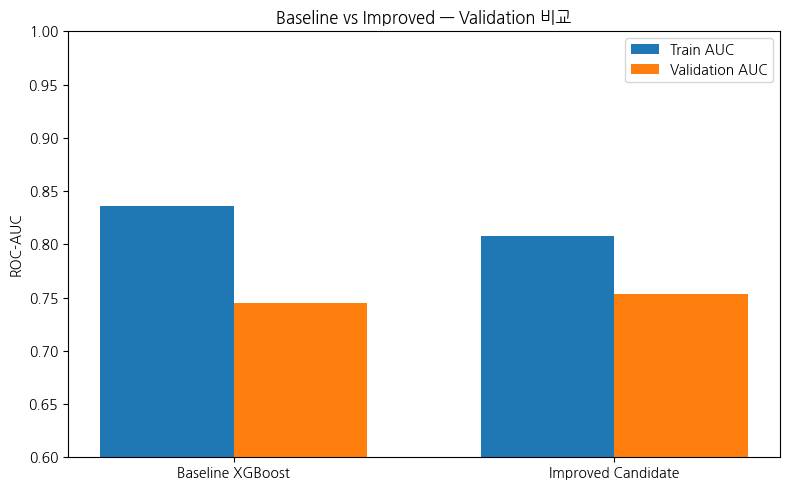

In [22]:
plot_df = validation_display.reset_index()

fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(plot_df))
width = 0.35

ax.bar(
    x - width / 2,
    plot_df["train_auc"],
    width,
    label="Train AUC",
)
ax.bar(
    x + width / 2,
    plot_df["valid_auc"],
    width,
    label="Validation AUC",
)
ax.set_xticks(x)
ax.set_xticklabels(plot_df["model_name"])
ax.set_ylim(0.60, 1.00)
ax.set_ylabel("ROC-AUC")
ax.set_title("Baseline vs Improved — Validation 비교")
ax.legend()

plt.tight_layout()
plt.savefig(
    f"{OUTPUT_DIR}/validation_auc_comparison.png",
    dpi=150,
)
plt.show()

## 13. Validation 기준 우선 후보 선정 — 핵심설계: 모델 선택 규칙 명시

우선 후보는 다음 규칙으로 선정한다.

1. Validation AUC가 최소 기준 0.70을 충족해야 한다.
2. 두 모델의 AUC 차이가 0.005보다 크면 AUC가 높은 모델을 선택한다.
3. AUC 차이가 0.005 이내이면 공정성 비율이 더 높은 모델을 우선한다.
4. 공정성 차이도 작으면 Train–Validation 격차가 더 작은 모델을 선택한다.
5. 나머지 지표도 비슷하면 Brier Score가 더 낮은 모델을 선택한다.

여기서 선정되는 모델은 **Audit 검증 전 우선 후보**다.
Audit에서 개선 효과가 재현되지 않으면 개선 성공으로 확정하지 않고 재실험 대상으로 처리한다.


In [23]:
def select_candidate_on_validation(
    comparison_df,
    min_auc=0.70,
    auc_tie=0.005,
    fairness_tie=0.01,
):
    eligible = comparison_df[
        comparison_df["valid_auc"] >= min_auc
    ].copy()

    if eligible.empty:
        raise ValueError(
            "모든 모델의 Validation AUC가 기준 미만입니다."
        )

    if len(eligible) == 1:
        winner = eligible.index[0]
        return winner, (
            f"{winner}만 Validation AUC "
            f"{min_auc:.2f} 기준을 충족"
        )

    ordered = eligible.sort_values(
        "valid_auc",
        ascending=False,
    )
    first, second = ordered.index[:2]

    auc_diff = abs(
        ordered.loc[first, "valid_auc"]
        - ordered.loc[second, "valid_auc"]
    )
    if auc_diff > auc_tie:
        return first, (
            f"Validation AUC 차이 "
            f"{auc_diff:.4f} > {auc_tie:.3f}"
        )

    fairness_diff = abs(
        ordered.loc[first, "valid_fairness_ratio"]
        - ordered.loc[second, "valid_fairness_ratio"]
    )
    if fairness_diff > fairness_tie:
        winner = ordered[
            "valid_fairness_ratio"
        ].idxmax()
        return winner, (
            f"AUC 차이 {auc_diff:.4f} 이내, "
            f"공정성 비율 차이 {fairness_diff:.4f}"
        )

    minimum_gap = eligible["train_valid_gap"].min()
    near_gap = eligible[
        eligible["train_valid_gap"]
        <= minimum_gap + 0.002
    ]

    if len(near_gap) == 1:
        winner = near_gap.index[0]
        return winner, (
            "AUC와 공정성이 유사하여 "
            "Train–Validation 격차가 작은 모델 선택"
        )

    winner = near_gap["valid_brier_score"].idxmin()
    return winner, (
        "AUC·공정성·과적합 격차가 유사하여 "
        "Brier Score가 낮은 모델 선택"
    )


selected_candidate_name, selection_reason = (
    select_candidate_on_validation(
        validation_comparison
    )
)

selected_candidate = (
    baseline_model
    if selected_candidate_name == "Baseline XGBoost"
    else improved_model
)

print("=" * 65)
print("Validation 기준 우선 후보:", selected_candidate_name)
print("선정 사유:", selection_reason)
print("다음 단계에서 Audit 일반화 검증을 실시합니다.")
print("=" * 65)

Validation 기준 우선 후보: Improved Candidate
선정 사유: Validation AUC 차이 0.0079 > 0.005
다음 단계에서 Audit 일반화 검증을 실시합니다.


## 14. Audit 최종 검증 및 기존 모델 비교 — 핵심설계: 고도화 효과 재현 확인

Validation 기준 우선 후보 선정이 끝난 뒤 Audit 데이터를 사용한다.

- Baseline과 Improved Candidate를 동일한 Audit 데이터에서 비교한다.
- 개선 후보가 Validation뿐 아니라 Audit에서도 성능 향상을 보이는지 확인한다.
- Audit 결과가 좋지 않은 개선 후보를 억지로 최종 고도화 모델로 확정하지 않는다.
- 개선 효과가 재현되지 않으면 **고도화 미확정·재실험 필요**로 기록한다.
- 다음 실험에서는 파라미터나 피처를 재검토하고 새로운 Holdout 또는 새로운 분할로 다시 검증한다.

즉, Audit 결과를 보고 즉석에서 점수가 높은 모델로 바꾸는 것이 아니라,
Validation에서 세운 가설이 새로운 데이터에서도 유지되는지를 검증하는 단계다.


In [24]:
baseline_audit_result = evaluate_audit(
    baseline_model,
    "Baseline XGBoost",
)
improved_audit_result = evaluate_audit(
    improved_model,
    "Improved Candidate",
)

audit_comparison = pd.DataFrame([
    baseline_audit_result,
    improved_audit_result,
]).set_index("model_name")

audit_columns = [
    "audit_auc",
    "audit_pr_auc",
    "audit_brier_score",
    "audit_log_loss",
    "audit_accuracy",
    "audit_gender_fairness_ratio",
    "audit_age_fairness_ratio",
    "audit_fairness_ratio",
]
audit_display = audit_comparison[
    audit_columns
].round(4)

audit_display.to_csv(
    f"{OUTPUT_DIR}/audit_model_comparison.csv",
    encoding="utf-8-sig",
)
display(audit_display)

,audit_auc,audit_pr_auc,audit_brier_score,audit_log_loss,audit_accuracy,audit_gender_fairness_ratio,audit_age_fairness_ratio,audit_fairness_ratio
model_name,,,,,,,,
Baseline XGBoost,0.7501,0.2384,0.1810,0.5391,0.7262,0.8425,0.5686,0.5686
Improved Candidate,0.7560,0.2470,0.0872,0.3077,0.8993,0.9566,0.8794,0.8794


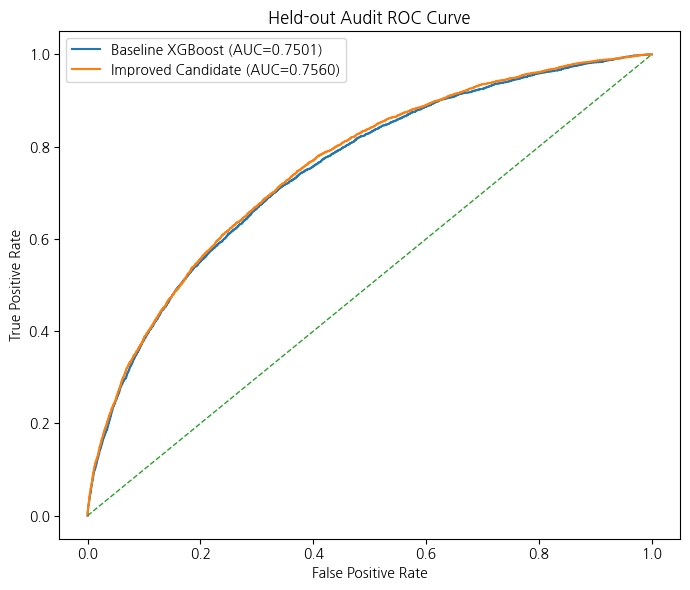

In [25]:
fig, ax = plt.subplots(figsize=(7, 6))

for model_name, row in audit_comparison.iterrows():
    ax.plot(
        row["fpr"],
        row["tpr"],
        label=(
            f"{model_name} "
            f"(AUC={row['audit_auc']:.4f})"
        ),
    )

ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1,
)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("Held-out Audit ROC Curve")
ax.legend()

plt.tight_layout()
plt.savefig(
    f"{OUTPUT_DIR}/audit_roc_comparison.png",
    dpi=150,
)
plt.show()

## 15. 최종 고도화 판정 및 모델 저장 — 핵심설계: 검증 통과 여부 기록

최종 판정은 다음과 같이 해석한다.

### 개선 후보가 Validation에서 선정되고 Audit에서도 Baseline 이상인 경우

- 고도화 효과가 재현된 것으로 기록
- 개선 후보를 `credit_model.json`으로 저장

### 개선 후보가 Validation에서 선정됐지만 Audit에서 성능이 하락한 경우

- 고도화 성공으로 확정하지 않음
- 개선 모델 배포 보류
- 기존 Baseline을 운영 안전 모델로 유지
- 재실험 필요 상태를 증적에 기록

### Baseline이 Validation에서 선정된 경우

- 이번 개선 파라미터가 기존 모델을 넘지 못한 것으로 기록
- Baseline을 공식 모델로 저장

이 단계의 “Baseline 유지”는 Audit 점수만 보고 후보를 다시 고르는 것이 아니라,
새 개선 모델이 최종 검증 게이트를 통과하지 못해 배포를 보류하는 의사결정이다.


In [26]:
baseline_audit_auc = float(
    audit_comparison.loc[
        "Baseline XGBoost",
        "audit_auc",
    ]
)
improved_audit_auc = float(
    audit_comparison.loc[
        "Improved Candidate",
        "audit_auc",
    ]
)
audit_auc_delta = (
    improved_audit_auc - baseline_audit_auc
)

if selected_candidate_name == "Improved Candidate":
    if audit_auc_delta >= 0:
        final_model_name = "Improved Candidate"
        final_model = improved_model
        final_status = "IMPROVEMENT_CONFIRMED"
        final_reason = (
            "Validation에서 개선 후보가 선정되었고 "
            "Audit에서도 Baseline 이상의 AUC를 재현함"
        )
    else:
        final_model_name = "Baseline XGBoost"
        final_model = baseline_model
        final_status = "RETEST_REQUIRED"
        final_reason = (
            "개선 후보가 Validation에서는 선정되었으나 "
            "Audit에서 성능 향상이 재현되지 않아 "
            "개선 모델 배포를 보류하고 재실험 필요"
        )
else:
    final_model_name = "Baseline XGBoost"
    final_model = baseline_model
    final_status = "BASELINE_RETAINED"
    final_reason = (
        "Validation 선정 단계에서 Baseline이 우수하여 "
        "이번 개선 후보를 채택하지 않음"
    )

print("Validation 우선 후보:", selected_candidate_name)
print("Audit AUC 변화(Improved - Baseline):", f"{audit_auc_delta:+.4f}")
print("최종 상태:", final_status)
print("저장 모델:", final_model_name)
print("판정 사유:", final_reason)

Validation 우선 후보: Improved Candidate
Audit AUC 변화(Improved - Baseline): +0.0059
최종 상태: IMPROVEMENT_CONFIRMED
저장 모델: Improved Candidate
판정 사유: Validation에서 개선 후보가 선정되었고 Audit에서도 Baseline 이상의 AUC를 재현함


In [27]:
official_model_path = f"{OUTPUT_DIR}/credit_model.json"
final_model.save_model(official_model_path)

# 저장한 모델을 다시 로드하여 피처 스키마가 유지되는지 확인
reloaded_model = xgb.XGBClassifier()
reloaded_model.load_model(official_model_path)

saved_feature_names = (
    reloaded_model.get_booster().feature_names
)
assert saved_feature_names == feature_cols, (
    "저장 모델과 학습 피처 스키마가 일치하지 않습니다."
)

feature_importance = pd.DataFrame({
    "feature": feature_cols,
    "importance": final_model.feature_importances_,
}).sort_values(
    "importance",
    ascending=False,
)
feature_importance.to_csv(
    f"{OUTPUT_DIR}/official_model_feature_importances.csv",
    index=False,
    encoding="utf-8-sig",
)

experiment_summary = {
    "random_state": RANDOM_STATE,
    "validation_selected_candidate": selected_candidate_name,
    "validation_selection_reason": selection_reason,
    "final_model": final_model_name,
    "final_status": final_status,
    "final_reason": final_reason,
    "audit_auc_delta_improved_minus_baseline": audit_auc_delta,
    "baseline_params": BASELINE_PARAMS,
    "improved_params": IMPROVED_PARAMS,
    "validation_metrics": (
        validation_display
        .reset_index()
        .to_dict("records")
    ),
    "audit_metrics": (
        audit_display
        .reset_index()
        .to_dict("records")
    ),
}
with open(
    f"{OUTPUT_DIR}/model_selection_evidence.json",
    "w",
    encoding="utf-8",
) as f:
    json.dump(
        experiment_summary,
        f,
        ensure_ascii=False,
        indent=2,
        default=str,
    )

print("✅ 공식 모델 저장:", official_model_path)
print("✅ 피처 스키마 일치:", len(feature_cols), "개")
print("✅ 모델 선정 증적 저장:",
      f"{OUTPUT_DIR}/model_selection_evidence.json")

✅ 공식 모델 저장: /content/drive/MyDrive/data/outputs_total/credit_model.json
✅ 피처 스키마 일치: 49 개
✅ 모델 선정 증적 저장: /content/drive/MyDrive/data/outputs_total/model_selection_evidence.json


## 16. PPT 워크시트용 데이터 정의서 및 AI 모델 정의서 생성

실험 결과를 발표자료에 바로 옮길 수 있도록 다음 파일을 생성한다.

- `ppt_dataset_definition.csv`
- `ppt_ai_model_definition.csv`
- `model_parameter_comparison.csv`
- `model_result_summary.csv`

실제 AUC와 최종 모델명은 노트북 실행 결과를 기준으로 자동 입력된다.


In [28]:
dataset_definition = pd.DataFrame([
    {
        "항목": "데이터셋명",
        "내용": "Home Credit Default Risk application_train.csv",
    },
    {
        "항목": "분석 목적",
        "내용": "신용평가 연체 가능성 예측 및 AI 규제준수 감사",
    },
    {
        "항목": "식별자",
        "내용": ID_COL,
    },
    {
        "항목": "정답 컬럼",
        "내용": "TARGET: 0 정상상환, 1 연체",
    },
    {
        "항목": "민감변수",
        "내용": ", ".join(SENSITIVE_COLS),
    },
    {
        "항목": "이상치 처리",
        "내용": (
            "CODE_GENDER XNA 제거, "
            "DAYS_EMPLOYED 365243→NaN, "
            "IS_RETIRED 생성"
        ),
    },
    {
        "항목": "범주형 처리",
        "내용": "pandas category + XGBoost enable_categorical",
    },
    {
        "항목": "결측치 처리",
        "내용": "별도 대치 없이 XGBoost 네이티브 처리",
    },
    {
        "항목": "데이터 분할",
        "내용": "Train 60% / Validation 20% / Audit 20%",
    },
    {
        "항목": "최종 학습 피처 수",
        "내용": len(feature_cols),
    },
])
dataset_definition.to_csv(
    f"{OUTPUT_DIR}/ppt_dataset_definition.csv",
    index=False,
    encoding="utf-8-sig",
)

model_definition = pd.DataFrame([
    {
        "항목": "Baseline 모델",
        "내용": "기존 XGBoost 비교 기준",
    },
    {
        "항목": "개선 후보",
        "내용": (
            "얕은 트리, 낮은 학습률, "
            "정규화 강화, 클래스 가중치 완화"
        ),
    },
    {
        "항목": "후보 선정 데이터",
        "내용": "Validation 데이터",
    },
    {
        "항목": "최종 검증 데이터",
        "내용": "학습·선정에 사용하지 않은 Audit 데이터",
    },
    {
        "항목": "Validation 우선 후보",
        "내용": selected_candidate_name,
    },
    {
        "항목": "최종 판정 상태",
        "내용": final_status,
    },
    {
        "항목": "최종 저장 모델",
        "내용": final_model_name,
    },
    {
        "항목": "Baseline Audit AUC",
        "내용": round(baseline_audit_auc, 4),
    },
    {
        "항목": "Improved Audit AUC",
        "내용": round(improved_audit_auc, 4),
    },
    {
        "항목": "Audit AUC 증감",
        "내용": round(audit_auc_delta, 4),
    },
])
model_definition.to_csv(
    f"{OUTPUT_DIR}/ppt_ai_model_definition.csv",
    index=False,
    encoding="utf-8-sig",
)

parameter_comparison = pd.DataFrame({
    "파라미터": sorted(
        set(BASELINE_PARAMS) | set(IMPROVED_PARAMS)
    ),
})
parameter_comparison["Baseline"] = (
    parameter_comparison["파라미터"]
    .map(BASELINE_PARAMS)
)
parameter_comparison["Improved"] = (
    parameter_comparison["파라미터"]
    .map(IMPROVED_PARAMS)
)
parameter_comparison.to_csv(
    f"{OUTPUT_DIR}/model_parameter_comparison.csv",
    index=False,
    encoding="utf-8-sig",
)

model_result_summary = pd.concat(
    [
        validation_display.add_prefix("validation_"),
        audit_display.add_prefix("audit_"),
    ],
    axis=1,
)
model_result_summary.to_csv(
    f"{OUTPUT_DIR}/model_result_summary.csv",
    encoding="utf-8-sig",
)

print("PPT 워크시트 파일 생성 완료")
print("-", f"{OUTPUT_DIR}/ppt_dataset_definition.csv")
print("-", f"{OUTPUT_DIR}/ppt_ai_model_definition.csv")
print("-", f"{OUTPUT_DIR}/model_parameter_comparison.csv")
print("-", f"{OUTPUT_DIR}/model_result_summary.csv")

PPT 워크시트 파일 생성 완료
- /content/drive/MyDrive/data/outputs_total/ppt_dataset_definition.csv
- /content/drive/MyDrive/data/outputs_total/ppt_ai_model_definition.csv
- /content/drive/MyDrive/data/outputs_total/model_parameter_comparison.csv
- /content/drive/MyDrive/data/outputs_total/model_result_summary.csv


## 17. 최종 산출물 확인

노트북을 처음부터 끝까지 실행하면 `model_outputs` 폴더에 다음 산출물이 생성된다.

### 데이터 전처리 산출물

- `train_processed.csv`
- `valid_processed.csv`
- `audit_dataset.csv`
- `feature_schema.json`
- `preprocessing_summary.json`
- `excluded_feature_definition.csv`

### 모델 및 비교 결과

- `baseline_xgboost.json`
- `improved_candidate_xgboost.json`
- `credit_model.json`
- `validation_model_comparison.csv`
- `audit_model_comparison.csv`
- `official_model_feature_importances.csv`
- `model_selection_evidence.json`

### 그래프 및 PPT 워크시트

- `target_distribution.png`
- `missing_ratio_top20.png`
- `validation_auc_comparison.png`
- `audit_roc_comparison.png`
- `ppt_dataset_definition.csv`
- `ppt_ai_model_definition.csv`
- `model_parameter_comparison.csv`
- `model_result_summary.csv`


In [29]:
generated_files = sorted(os.listdir(OUTPUT_DIR))
print(f"총 {len(generated_files)}개 파일")
for file_name in generated_files:
    print("-", file_name)

총 21개 파일
- audit_dataset.csv
- audit_model_comparison.csv
- audit_roc_comparison.png
- baseline_xgboost.json
- credit_model.json
- excluded_feature_definition.csv
- feature_schema.json
- improved_candidate_xgboost.json
- missing_ratio_top20.png
- model_parameter_comparison.csv
- model_result_summary.csv
- model_selection_evidence.json
- official_model_feature_importances.csv
- ppt_ai_model_definition.csv
- ppt_dataset_definition.csv
- preprocessing_summary.json
- target_distribution.png
- train_processed.csv
- valid_processed.csv
- validation_auc_comparison.png
- validation_model_comparison.csv
